In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style("whitegrid")

In [3]:
def plot(data: pd.DataFrame):
    g = sns.displot(
        data=data,
        x="norm",
        col="model",        
        row="layer",        
        kind="hist",   
        height=2.5,         
        aspect=1,       
        stat='probability',
        bins=20,
        common_norm=False,
        common_bins=False,
        edgecolor="white",  
        linewidth=0.5,
        kde=True,
        facet_kws={
            'sharex': False, 
            'sharey': False  
        }
    )

    for ax in g.axes.flatten():
        if not ax.patches and not ax.lines:
            ax.set_visible(False)
        else:
            ax.grid(axis='y', linestyle='--', alpha=0.5)
            ax.grid(axis='x', linestyle='--', alpha=0.5)
            ax.tick_params(labelbottom=True, labelleft=True)

    g.figure.subplots_adjust(hspace=0.5, wspace=0.8)
    plt.savefig("./figs/plot.png", dpi=300)

In [4]:
takes = {
    'pythia-14m': pd.read_csv("../data/2026-02-23-00-45-08_pythia-14m.csv"),
    'pythia-160m': pd.read_csv("../data/2026-02-23-00-45-18_pythia-160m.csv"),
    'pythia-410m': pd.read_csv("../data/2026-02-23-00-45-32_pythia-410m.csv"),
    'pythia-1b': pd.read_csv("../data/2026-02-23-00-45-59_pythia-1b.csv"),
    'pythia-1.4b': pd.read_csv("../data/2026-02-23-00-46-30_pythia-1-4b.csv"),
    'pythia-2.8b': pd.read_csv("../data/2026-02-23-00-47-46_pythia-2-8b.csv"),
}

data = pd.concat([df.assign(model=model) for model, df in takes.items()], ignore_index=True)

data

,layer,norm,model
0,0,1.187566,pythia-14m
1,0,0.969369,pythia-14m
2,0,1.128724,pythia-14m
3,0,1.130039,pythia-14m
4,0,1.150060,pythia-14m
...,...,...,...
13393855,31,142.491531,pythia-2.8b
13393856,31,167.155640,pythia-2.8b
13393857,31,163.796112,pythia-2.8b
13393858,31,142.611710,pythia-2.8b


FileNotFoundError: [Errno 2] No such file or directory: './figs/plot.png'

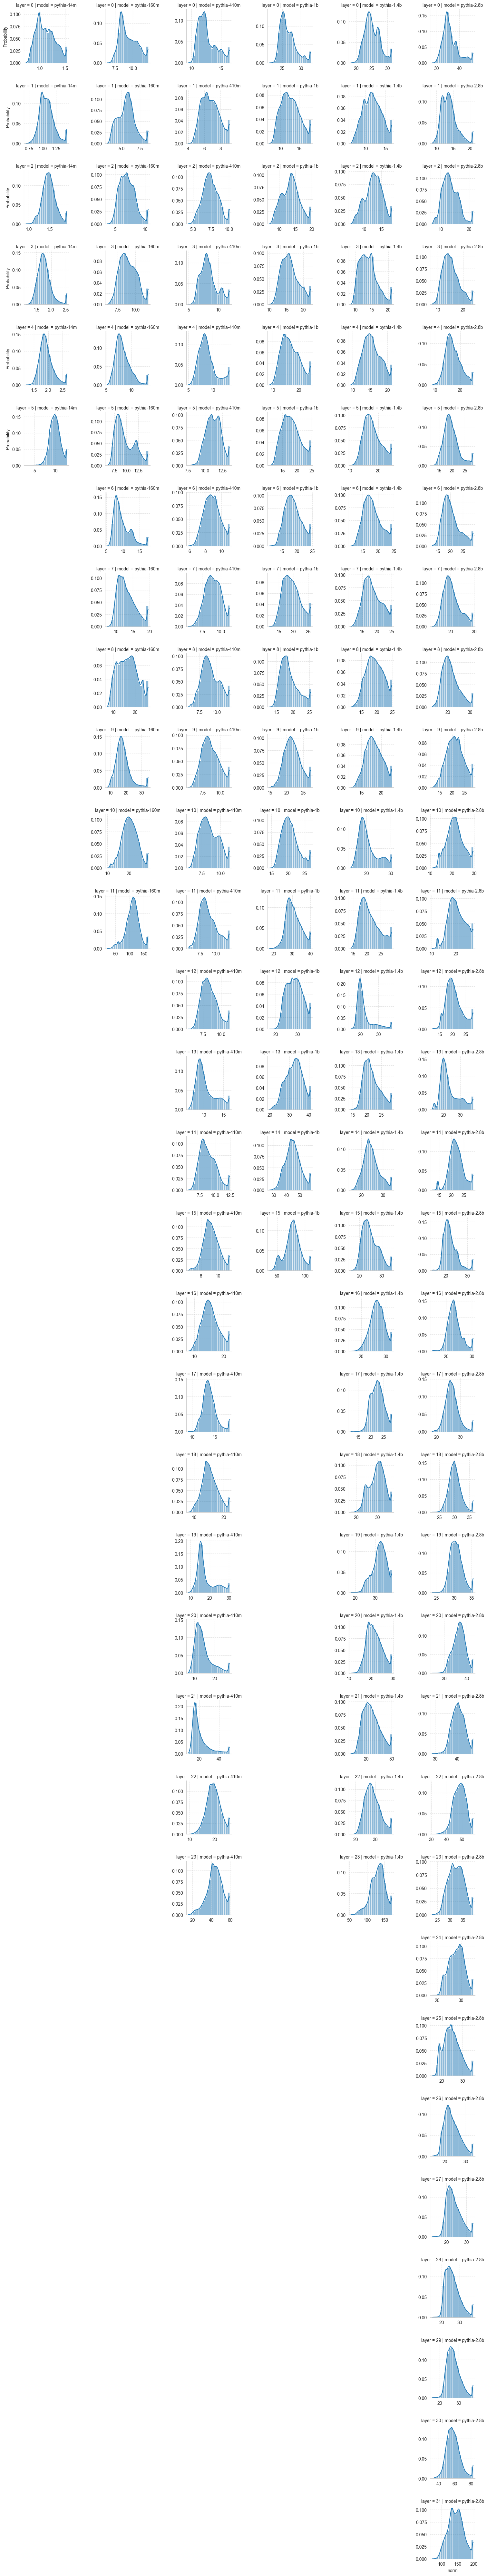

In [5]:
upper_bound = data.groupby(['layer', 'model'])['norm'].transform(lambda x: x.quantile(0.975))

clipped_data = data.copy()
clipped_data['norm'] = clipped_data['norm'].clip(upper=upper_bound)

plot(clipped_data)